# 00 - Dataset overview and data-quality checks

Facts about the spring inventory that the report quotes: class balance, drying years,
survey dates, the reported cause of drying, data-quality checks, the descriptive terrain
and road figures, the external (non-Roshi) springs, and the size of the proposed temporal
augmentation. All numbers are saved to `results/tables/dataset_facts.json`.

In [1]:
import sys, json, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))  # run from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from spring_drying.config import (FIGURES_DIR, TABLES_DIR, RANDOM_STATE, WINDOW_END, WINDOW_LEN,
                                  SURVEY_YEAR, ERA5_LAND_FIRST_YEAR, RAW_SURVEY_PATH, NC_PATH)
from spring_drying.data import load_springs, attach_drying_reason

sns.set_style("whitegrid")
pd.set_option("display.width", 140)

def save_json(obj, name):
    def conv(o):
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, (np.ndarray,)): return o.tolist()
        raise TypeError(type(o))
    with open(TABLES_DIR / name, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=conv)
    print("saved", TABLES_DIR / name)

In [2]:
from spring_drying.data import _coord_key
from spring_drying.climate import grid_cell_ids

springs = attach_drying_reason(load_springs())
facts = {}
n, nd = len(springs), int(springs["dried"].sum())
facts["n_springs"], facts["n_dried"], facts["n_active"] = n, nd, n - nd
facts["pct_dried"] = 100 * nd / n
facts["n_perennial"] = int(springs["perennial"].sum())
facts["n_seasonal"] = n - facts["n_perennial"]
facts["pct_perennial"] = 100 * facts["n_perennial"] / n
facts["pct_dried_perennial"] = 100 * springs.loc[springs["perennial"] == 1, "dried"].mean()
facts["pct_dried_seasonal"] = 100 * springs.loc[springs["perennial"] == 0, "dried"].mean()
print(pd.crosstab(springs["Perennial / Seasonal"], springs["Source Condition"], margins=True))
facts

Source Condition      active  dried   All
Perennial / Seasonal                     
perennial               2352    432  2784
seasonal                 208    295   503
All                     2560    727  3287


{'n_springs': 3287,
 'n_dried': 727,
 'n_active': 2560,
 'pct_dried': 22.11743230909644,
 'n_perennial': 2784,
 'n_seasonal': 503,
 'pct_perennial': 84.69729236385763,
 'pct_dried_perennial': np.float64(15.517241379310345),
 'pct_dried_seasonal': np.float64(58.64811133200796)}

## Drying year (calendar year, AD)

The analysis table stores the year a spring dried in a column misleadingly named
*"Dried since how many years?"*. A complete 15-year ERA5-Land window needs an end year of
at least 1950 + 14 = 1964.

In [3]:
dy = springs.loc[springs["dried"] == 1, "dried_year"]
first_full_end = ERA5_LAND_FIRST_YEAR + WINDOW_LEN - 1
facts["drying_year"] = {
    "n_with_year": int(dy.notna().sum()), "n_missing": int(dy.isna().sum()),
    "min": int(dy.min()), "max": int(dy.max()), "median": float(dy.median()),
    "n_2015": int((dy == 2015).sum()), "pct_2015": 100 * float((dy == 2015).sum()) / nd,
    "first_complete_window_end": first_full_end,
    "n_before_first_complete": int((dy < first_full_end).sum()),
    "n_since_2000": int((dy >= 2000).sum()),
}
facts["drying_year"]

{'n_with_year': 723,
 'n_missing': 4,
 'min': 1943,
 'max': 2023,
 'median': 2015.0,
 'n_2015': 241,
 'pct_2015': 33.14993122420908,
 'first_complete_window_end': 1964,
 'n_before_first_complete': 5,
 'n_since_2000': 653}

## Raw survey: size, survey dates and the Bikram Sambat calendar

In [4]:
raw = pd.read_csv(RAW_SURVEY_PATH, low_memory=False, encoding="latin-1").dropna(how="all")
stype = raw["Source Type"].astype(str).str.strip().str.lower()
facts["raw"] = {"n_records": len(raw), "n_springs": int((stype == "spring").sum()),
                "n_ponds": int((stype == "pond").sum()),
                "springs_by_municipality": raw.loc[stype == "spring", "Municipality"].value_counts().to_dict()}

dates = pd.to_datetime(raw["Date"].astype(str).str.strip(), format="%d/%m/%Y", errors="coerce")
ok = dates[dates.dt.year.isin([2023, 2024])]
facts["survey_dates"] = {
    "n_records_with_date": int(raw["Date"].notna().sum()), "n_parsed_2023_2024": int(len(ok)),
    "pct_2024": 100 * float((ok.dt.year == 2024).mean()),
    "p05": str(ok.quantile(0.05).date()), "median": str(ok.quantile(0.5).date()), "p95": str(ok.quantile(0.95).date()),
}
print(ok.dt.to_period("M").value_counts().sort_index())

# Bikram Sambat (BS) drying years in the raw survey vs AD years in the analysis table
r = raw.dropna(subset=["Latitude", "Longitude"])
r = r[r["Source Condition"].astype(str).str.strip().str.lower() == "dried"]
r = r.assign(k=_coord_key(r)).drop_duplicates("k")
dried = springs[springs["dried"] == 1]
bs = pd.to_numeric(_coord_key(dried).map(r.set_index("k")["Dried since how many years?"]), errors="coerce")
offset = (bs.values - dried["dried_year"].values)
offset = pd.Series(offset[~np.isnan(offset)]).astype(int).value_counts()
facts["bs_to_ad_offset"] = {str(k): int(v) for k, v in offset.items()}
facts["survey_dates"], facts["bs_to_ad_offset"]

Date
2023-01      23
2023-12     654
2024-01    1319
2024-02    1042
2024-03     751
2024-04    1057
2024-05       3
Freq: M, Name: count, dtype: int64


({'n_records_with_date': 5022,
  'n_parsed_2023_2024': 4849,
  'pct_2024': 86.03835842441741,
  'p05': '2023-12-18',
  'median': '2024-02-08',
  'p95': '2024-04-18'},
 {'57': 721, '53': 1, '49': 1})

## Reported cause of drying

Matched from the raw survey's *Reason of drying* field by coordinates
(*Drought* and *Reduced Precipitation* are grouped as **drought**).

drying_reason
earthquake               229
drought                  226
infrastructure           105
neglect_or_disruption     95
natural_disaster          64
land_use                   5
unknown                    3
Name: count, dtype: int64
earthquake-dried springs that dried in 2015: 195


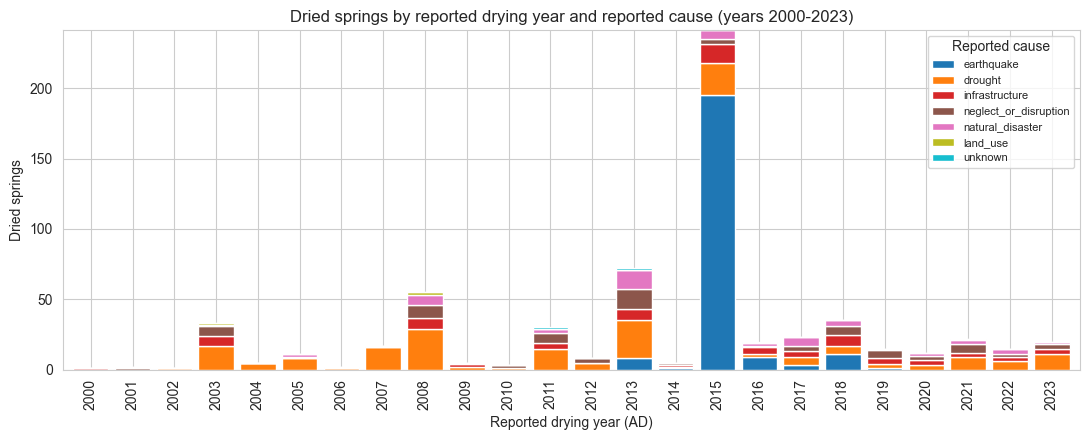

In [5]:
cause = springs.loc[springs["dried"] == 1, "drying_reason"].value_counts()
facts["drying_cause"] = cause.to_dict()
eq = springs[(springs["dried"] == 1) & (springs["drying_reason"] == "earthquake")]
facts["earthquake_dried_in_2015"] = int((eq["dried_year"] == 2015).sum())
facts["n_dried_2015_by_cause"] = springs[(springs["dried"] == 1) & (springs["dried_year"] == 2015)]["drying_reason"].value_counts().to_dict()
facts["drought_drying_year_median"] = float(springs.loc[springs["drying_reason"] == "drought", "dried_year"].median())
print(cause); print("earthquake-dried springs that dried in 2015:", facts["earthquake_dried_in_2015"])

recent = springs[(springs["dried"] == 1) & (springs["dried_year"] >= 2000)]
tab = pd.crosstab(recent["dried_year"].astype(int), recent["drying_reason"])
order = [c for c in ["earthquake", "drought", "infrastructure", "neglect_or_disruption", "natural_disaster", "land_use", "unknown"] if c in tab.columns]
ax = tab[order].plot.bar(stacked=True, figsize=(11, 4.5), width=0.85, colormap="tab10")
ax.set_xlabel("Reported drying year (AD)"); ax.set_ylabel("Dried springs")
ax.set_title("Dried springs by reported drying year and reported cause (years 2000-2023)")
ax.legend(title="Reported cause", fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "overview_drying_year_by_cause.png", dpi=300); plt.show()

## Data-quality checks and climate grid cells

In [6]:
geo_cols = ["geometry", "buffer", "LU", "drying_reason"]
facts["quality"] = {
    "duplicate_coordinates": int(springs.duplicated(["Latitude", "Longitude"]).sum()),
    "identical_rows": int(springs.drop(columns=[c for c in geo_cols if c in springs]).duplicated().sum()),
    "slope_sin_min": float(springs["Slope_sin"].min()), "slope_sin_max": float(springs["Slope_sin"].max()),
    "slope_cos_max": float(springs["Slope_cos"].max()),
    "n_missing_formation": int(springs["Formation"].isna().sum()),
}
groups = grid_cell_ids(springs["Latitude"].values, springs["Longitude"].values)
per_cell = springs.assign(cell=groups).groupby("cell")["dried"].agg(["size", "mean"])
facts["grid"] = {"n_cells": int(per_cell.shape[0]), "springs_per_cell_min": int(per_cell["size"].min()),
                 "springs_per_cell_max": int(per_cell["size"].max()),
                 "dried_pct_per_cell_min": 100 * float(per_cell["mean"].min()),
                 "dried_pct_per_cell_max": 100 * float(per_cell["mean"].max()),
                 "cells_all_active": int((per_cell["mean"] == 0).sum())}
print(per_cell.sort_values("size", ascending=False))
facts["quality"], facts["grid"]

       size      mean
cell                 
49979  1065  0.146479
50382   530  0.347170
49980   515  0.273786
50381   477  0.199161
50380   272  0.191176
50784   119  0.235294
50783   112  0.062500
50383   111  0.441441
49978    45  0.111111
49981    32  0.312500
50379     8  0.000000
49578     1  0.000000


({'duplicate_coordinates': 51,
  'identical_rows': 36,
  'slope_sin_min': 0.9999989,
  'slope_sin_max': 1.0,
  'slope_cos_max': 0.001446203,
  'n_missing_formation': 26},
 {'n_cells': 12,
  'springs_per_cell_min': 1,
  'springs_per_cell_max': 1065,
  'dried_pct_per_cell_min': 0.0,
  'dried_pct_per_cell_max': 44.14414414414414,
  'cells_all_active': 2})

## Descriptive terrain and road figures

Regenerated from `Full_Analysis_data.csv` so the figures in the report are reproducible.

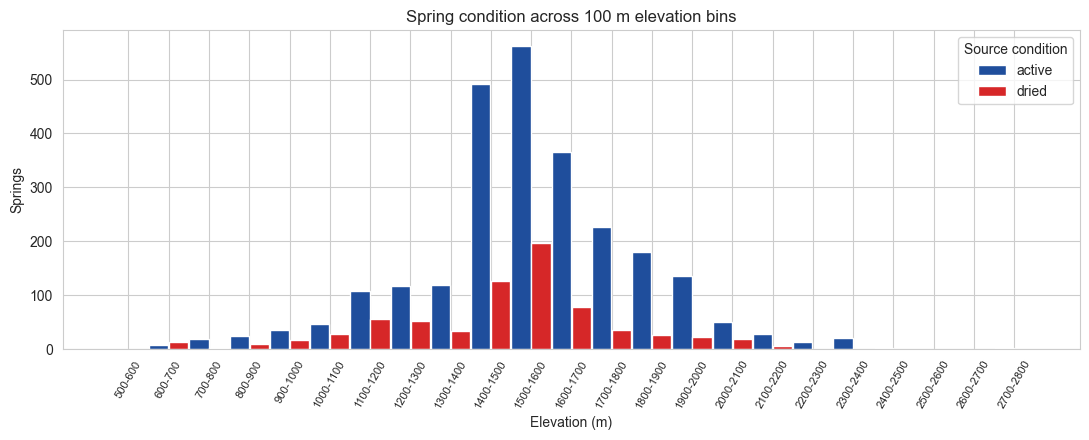

           size      mean
Elev                     
<1000       131  0.335878
1000-1400   565  0.306195
1400-1700  1820  0.220330
1700-2000   626  0.134185
>2000       145  0.172414


In [7]:
colors = {"active": "#1f4e9c", "dried": "#d62728"}
cond = springs["Source Condition"].str.strip().str.lower()

# Elevation in 100 m bins
bins = np.arange(500, 2900, 100)
fig, ax = plt.subplots(figsize=(11, 4.5))
for i, c in enumerate(["active", "dried"]):
    counts, _ = np.histogram(springs.loc[cond == c, "Elev"], bins=bins)
    ax.bar(bins[:-1] + 25 + 50 * i, counts, width=48, color=colors[c], label=c)
ax.set_xticks(bins[:-1] + 50); ax.set_xticklabels([f"{b}-{b+100}" for b in bins[:-1]], rotation=60, fontsize=8)
ax.set_xlabel("Elevation (m)"); ax.set_ylabel("Springs"); ax.legend(title="Source condition")
ax.set_title("Spring condition across 100 m elevation bins")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "overview_elevation_bins.png", dpi=300); plt.show()

bands = pd.cut(springs["Elev"], [0, 1000, 1400, 1700, 2000, 3000],
               labels=["<1000", "1000-1400", "1400-1700", "1700-2000", ">2000"])
by_band = springs.groupby(bands, observed=True)["dried"].agg(["size", "mean"])
facts["elevation"] = {"median": float(springs["Elev"].median()), "min": float(springs["Elev"].min()),
                      "max": float(springs["Elev"].max()),
                      "n_1400_1700": int(by_band.loc["1400-1700", "size"]),
                      "dried_pct_by_band": {str(k): 100 * float(v) for k, v in by_band["mean"].items()},
                      "springs_by_band": {str(k): int(v) for k, v in by_band["size"].items()}}
print(by_band)

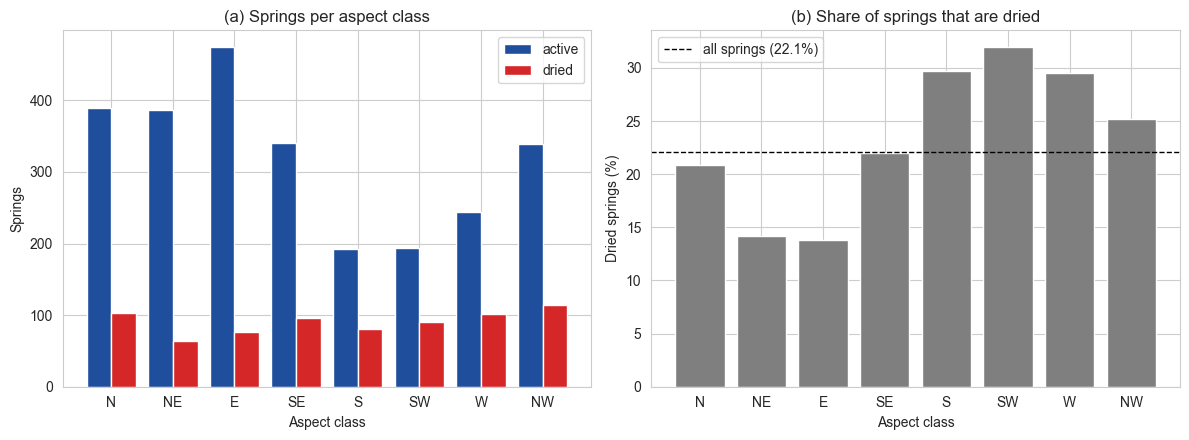

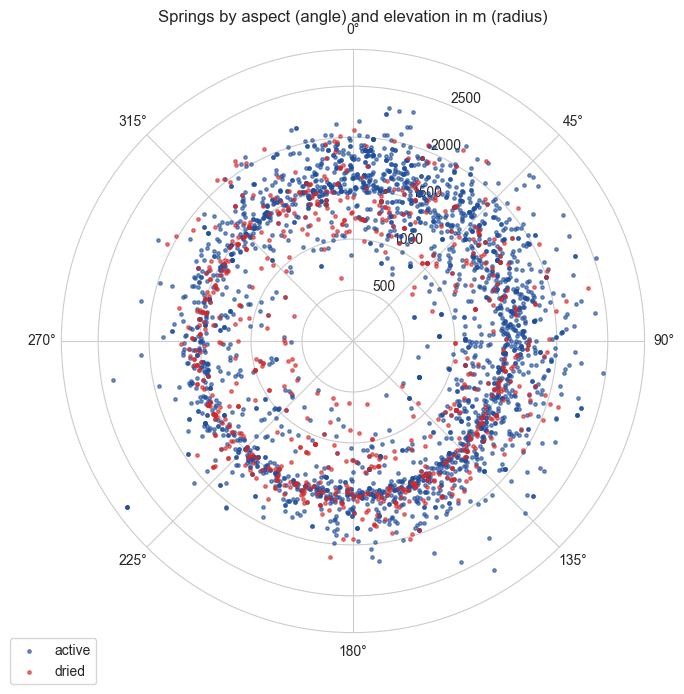

{'counts': {'N': {'active': 390, 'dried': 103},
  'NE': {'active': 386, 'dried': 64},
  'E': {'active': 474, 'dried': 76},
  'SE': {'active': 341, 'dried': 96},
  'S': {'active': 192, 'dried': 81},
  'SW': {'active': 194, 'dried': 91},
  'W': {'active': 244, 'dried': 102},
  'NW': {'active': 339, 'dried': 114}},
 'dried_pct': {'N': 20.89,
  'NE': 14.22,
  'E': 13.82,
  'SE': 21.97,
  'S': 29.67,
  'SW': 31.93,
  'W': 29.48,
  'NW': 25.17}}

In [8]:
aspect_classes = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
asp = springs[[f"Aspect-{a}" for a in aspect_classes]].astype(bool)
asp.columns = aspect_classes
klass = asp.idxmax(axis=1)
counts = pd.crosstab(klass, cond).reindex(aspect_classes)
share = 100 * counts["dried"] / counts.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(aspect_classes))
axes[0].bar(x - 0.2, counts["active"], 0.4, color=colors["active"], label="active")
axes[0].bar(x + 0.2, counts["dried"], 0.4, color=colors["dried"], label="dried")
axes[0].set_xticks(x); axes[0].set_xticklabels(aspect_classes); axes[0].set_ylabel("Springs")
axes[0].set_xlabel("Aspect class"); axes[0].legend(); axes[0].set_title("(a) Springs per aspect class")
axes[1].bar(x, share, color="#7f7f7f")
axes[1].axhline(100 * nd / n, color="k", ls="--", lw=1, label=f"all springs ({100*nd/n:.1f}%)")
axes[1].set_xticks(x); axes[1].set_xticklabels(aspect_classes); axes[1].set_ylabel("Dried springs (%)")
axes[1].set_xlabel("Aspect class"); axes[1].legend(); axes[1].set_title("(b) Share of springs that are dried")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "overview_aspect.png", dpi=300); plt.show()
facts["aspect"] = {"counts": counts.to_dict(orient="index"), "dried_pct": share.round(2).to_dict()}

# Polar scatter: aspect (angle, compass) and elevation (radius)
fig = plt.figure(figsize=(7, 7)); ax = fig.add_subplot(projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
for c in ["active", "dried"]:
    sub = springs[cond == c]
    ax.scatter(np.deg2rad(sub["Aspect"]), sub["Elev"], s=6, alpha=0.6, color=colors[c], label=c)
ax.set_title("Springs by aspect (angle) and elevation in m (radius)", pad=20)
ax.legend(loc="lower left", bbox_to_anchor=(-0.1, -0.1))
plt.tight_layout(); plt.savefig(FIGURES_DIR / "overview_elevation_aspect_polar.png", dpi=300); plt.show()
facts["aspect"]

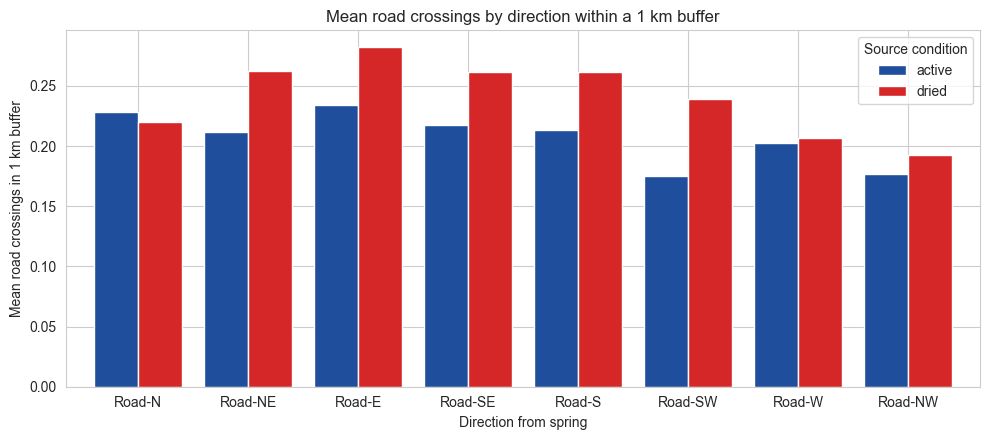

{'mean_by_direction': {'active': {'Road-N': 0.2285,
   'Road-NE': 0.2117,
   'Road-E': 0.2344,
   'Road-SE': 0.2176,
   'Road-S': 0.2133,
   'Road-SW': 0.1754,
   'Road-W': 0.2023,
   'Road-NW': 0.1766},
  'dried': {'Road-N': 0.2201,
   'Road-NE': 0.2627,
   'Road-E': 0.282,
   'Road-SE': 0.2613,
   'Road-S': 0.2613,
   'Road-SW': 0.2393,
   'Road-W': 0.2063,
   'Road-NW': 0.1926}},
 'directions_dried_higher': ['Road-NE',
  'Road-E',
  'Road-SE',
  'Road-S',
  'Road-SW',
  'Road-W',
  'Road-NW'],
 'mean_total_active': 1.659765625,
 'mean_total_dried': 1.9257221458046767}

In [9]:
road_cols = [f"Road-{a}" for a in aspect_classes]
means = springs.groupby(cond)[road_cols].mean().T
ax = means.plot.bar(figsize=(10, 4.5), color=[colors["active"], colors["dried"]], width=0.8)
ax.set_xlabel("Direction from spring"); ax.set_ylabel("Mean road crossings in 1 km buffer")
ax.set_title("Mean road crossings by direction within a 1 km buffer"); ax.legend(title="Source condition")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(FIGURES_DIR / "overview_road_crossings.png", dpi=300); plt.show()
total = springs[road_cols].sum(axis=1)
facts["roads"] = {"mean_by_direction": means.round(4).to_dict(),
                  "directions_dried_higher": [d for d in road_cols if means.loc[d, "dried"] > means.loc[d, "active"]],
                  "mean_total_active": float(total[cond == "active"].mean()),
                  "mean_total_dried": float(total[cond == "dried"].mean())}
facts["roads"]

## Springs outside the analysis set (future transfer test)

Springs in the 7-municipality inventory that are not among the 3,287 analysis springs,
and how many fall in ERA5-Land cells that are *not* used by any Roshi spring.

In [10]:
sp = raw[stype == "spring"].dropna(subset=["Latitude", "Longitude"]).copy()
outside = sp[~_coord_key(sp).isin(set(_coord_key(springs)))].copy()
outside["cell"] = grid_cell_ids(outside["Latitude"].values, outside["Longitude"].values)
outside["new_cell"] = ~outside["cell"].isin(set(groups))
outside["dried"] = outside["Source Condition"].astype(str).str.strip().str.lower().eq("dried")
tab = outside.groupby("Municipality").agg(springs=("cell", "size"), cells=("cell", "nunique"),
                                          pct_in_new_cells=("new_cell", lambda s: 100 * s.mean()),
                                          pct_dried=("dried", lambda s: 100 * s.mean()))
facts["outside"] = {"n_springs": int(len(outside)), "pct_in_new_cells": 100 * float(outside["new_cell"].mean()),
                    "by_municipality": tab.round(1).to_dict(orient="index")}
tab.round(1)

,springs,cells,pct_in_new_cells,pct_dried
Municipality,,,,
Bethanchownk,65,2,0.0,10.8
Dhulikhel,596,5,22.1,20.6
Namobuudha,55,3,0.0,9.1
Panauti,2,1,0.0,100.0
Panchkhal,837,4,37.3,38.9
Roshi RM,4,2,25.0,75.0
Temal,497,5,0.2,32.6


## Size of the temporal augmentation proposed in the report (Section 6.5 of the submitted version)

Rows per active spring for years 2015-2023, rows per dried spring for its drying year to 2023
(drying year >= 1964 so a complete window exists).

In [11]:
years_active = list(range(2015, SURVEY_YEAR + 1))
dy_ok = dy[dy >= first_full_end]
aug_active = facts["n_active"] * len(years_active)
aug_dried = int((SURVEY_YEAR - dy_ok + 1).sum())
pre = int(sum(min(2014, SURVEY_YEAR) - y + 1 for y in dy_ok if y <= 2014))
facts["augmentation"] = {"rows_per_active": len(years_active), "rows_active": aug_active, "rows_dried": aug_dried,
                         "pct_dried_after": 100 * aug_dried / (aug_active + aug_dried),
                         "dried_rows_before_2015": pre, "pct_dried_rows_before_2015": 100 * pre / aug_dried}
save_json(facts, "dataset_facts.json")
facts["augmentation"]

saved C:\Users\kants\OneDrive\Desktop\ME Classes\3rd Sem\Thesis & Project\Python program\results\tables\dataset_facts.json


{'rows_per_active': 9,
 'rows_active': 23040,
 'rows_dried': 8795,
 'pct_dried_after': 27.626825820637663,
 'dried_rows_before_2015': 3021,
 'pct_dried_rows_before_2015': 34.34906196702672}